# Tarea M3 · Regresión aplicada a un ramo de seguros

**Equipo 3**

Integrantes:

-
- Ruiz Carbajal Ismael
-


---

## 1. Selección del ramo y justificación

Se evaluaron los cuatro ramos disponibles en la cartera (`GMM`, `Autos`, `Vida`, `Accidentes Personales`). En un primer avance se había seleccionado **Autos**, pero al revisar la prima se detectaron valores poco consistentes para ese ramo, y ya existía trabajo previo del equipo (encoding de variables) sobre **GMM** en otro ejercicio del diplomado. Por ello el equipo decide trabajar con el ramo de **Gastos Médicos Mayores (GMM)**, justificado por:

- Es el ramo con mayor número de observaciones de la cartera (22,531 pólizas de 50,000, ~45%).
- Sus variables clave (`suma_asegurada`, `deducible`, `prima_neta`, `prima_total`, `n_siniestros`, `monto_pagado`) tienen muy pocos o nulos valores faltantes, a diferencia de Autos, donde `marca_vehiculo`/`tipo_vehiculo` faltan en el 100% de las pólizas que no son de Autos y complican comparaciones cruzadas.
- Tiene variables categóricas relevantes para tarificación (`plan`, `nivel_riesgo`, `ocupacion`) que permiten construir modelos de regresión múltiple y logística con sentido actuarial.
- Continuidad de trabajo en equipo: parte del preprocesamiento (codificación de variables categóricas) ya se había explorado en un ejercicio anterior con este mismo ramo.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                              accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix)
import statsmodels.api as sm
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

cartera = pd.read_parquet("cartera_q1_2026_final.parquet")
cartera["ramo"].value_counts()

ramo
GMM                      22531
Autos                    14752
Vida                      7510
Accidentes Personales     5207
Name: count, dtype: int64

In [2]:
cartera.groupby("ramo").agg(
    polizas=("id_poliza", "count"),
    prima_promedio=("prima_total", "mean"),
    siniestros_promedio=("n_siniestros", "mean"),
    monto_reclamado=("monto_reclamado", "mean"),
    loss_ratio=("loss_ratio", "mean")
).round(2)

,polizas,prima_promedio,siniestros_promedio,monto_reclamado,loss_ratio
ramo,,,,,
Accidentes Personales,5207,4797.52,0.35,12990.09,0.41
Autos,14752,17206.04,0.36,13473.50,0.25
GMM,22531,32445.18,0.36,13403.79,0.20
Vida,7510,60496.95,0.36,12780.06,0.12


## 2. Análisis exploratorio (EDA)

Se reutiliza y adapta la clase `AnalizadorRamo` construida previamente por el equipo para el ramo de Autos. Se sustituyen los gráficos específicos de vehículo (`marca_vehiculo`, `tipo_vehiculo`, que no existen para GMM) por variables propias de este ramo: `ocupacion` y `nivel_riesgo`.

In [3]:
class AnalizadorRamo:

    def __init__(self, dataframe, nombre_ramo):
        self.df_completo = dataframe
        self.ramo = nombre_ramo
        self.df_ramo = dataframe[dataframe['ramo'] == nombre_ramo].copy()

    # 1. Estadisticas generales
    def calcular_estadisticas(self):
        estadisticas = self.df_ramo.groupby('ramo').agg(
            numero_polizas=('id_poliza', 'nunique'),
            prima_total=('prima_total', 'sum'),
            prima_promedio=('prima_total', 'mean'),
            siniestros_totales=('n_siniestros', 'sum'),
            monto_reclamado_total=('monto_reclamado', 'sum'),
            monto_pagado_total=('monto_pagado', 'sum'),
            siniestro_promedio=('monto_pagado', 'mean'),
            suma_asegurada_promedio=('suma_asegurada', 'mean'),
            edad_promedio=('edad', 'mean')
        ).round(2)
        return estadisticas

    # 2. Estadisticas descriptivas
    def estadisticas_numericas(self):
        variables = ['edad', 'prima_total', 'prima_neta', 'suma_asegurada',
                     'n_siniestros', 'monto_reclamado', 'monto_pagado', 'loss_ratio']
        return self.df_ramo[variables].describe().round(2)

    # 3. Distribuciones (adaptado a GMM: se cambia marca/tipo de vehiculo por ocupacion/nivel_riesgo)
    def graficar(self):
        self.df_ramo['anio_inicio'] = pd.to_datetime(self.df_ramo['fecha_inicio_vigencia']).dt.year

        fig, axes = plt.subplots(3, 3, figsize=(18, 15))
        fig.suptitle(f'Analisis Exploratorio - {self.ramo}', fontsize=18)

        self.df_ramo['sexo'].value_counts().plot(kind='bar', ax=axes[0,0], color='skyblue', edgecolor='black')
        axes[0,0].set_title('Sexo')

        axes[0,1].hist(self.df_ramo['edad'], bins=15, color='salmon', edgecolor='black')
        axes[0,1].set_title('Edad')

        axes[0,2].hist(self.df_ramo['anio_inicio'], bins=6, color='lightgreen', edgecolor='black')
        axes[0,2].set_title('Anio Inicio Vigencia')

        self.df_ramo['plan'].value_counts().plot(kind='bar', ax=axes[1,0], color='orchid', edgecolor='black')
        axes[1,0].set_title('Plan')

        axes[1,1].hist(self.df_ramo['prima_total'], bins=20, color='gold', edgecolor='black')
        axes[1,1].set_title('Prima Total')

        axes[1,2].hist(self.df_ramo['n_siniestros'], bins=10, color='lightcoral', edgecolor='black')
        axes[1,2].set_title('Numero de Siniestros')

        self.df_ramo['ocupacion'].value_counts().head(10).plot(kind='bar', ax=axes[2,0], color='steelblue', edgecolor='black')
        axes[2,0].set_title('Top 10 Ocupaciones')

        self.df_ramo['nivel_riesgo'].value_counts().plot(kind='bar', ax=axes[2,1], color='tomato', edgecolor='black')
        axes[2,1].set_title('Nivel de Riesgo')

        axes[2,2].hist(self.df_ramo['suma_asegurada'], bins=20, color='mediumpurple', edgecolor='black')
        axes[2,2].set_title('Suma Asegurada')

        plt.tight_layout()
        plt.show()

    # 4. Correlaciones
    def matriz_correlacion(self):
        columnas = ['edad', 'prima_total', 'prima_neta', 'suma_asegurada',
                    'n_siniestros', 'monto_reclamado', 'monto_pagado', 'loss_ratio']
        correlacion = self.df_ramo[columnas].corr()
        plt.figure(figsize=(10,8))
        sns.heatmap(correlacion, annot=True, cmap='coolwarm', fmt='.2f')
        plt.title('Matriz de Correlacion')
        plt.show()

# 5. Boxplots
    def boxplots(self):
        fig, axes = plt.subplots(2,2, figsize=(12,8))
        sns.boxplot(y=self.df_ramo['prima_total'], ax=axes[0,0]); axes[0,0].set_title('Prima Total')
        sns.boxplot(y=self.df_ramo['suma_asegurada'], ax=axes[0,1]); axes[0,1].set_title('Suma Asegurada')

        # monto_pagado y loss_ratio: se filtran las polizas sin siniestro (valor 0)
        # porque son ~70% de la cartera y aplastan la caja del boxplot contra el eje.
        pagado_con_siniestro = self.df_ramo.loc[self.df_ramo['monto_pagado'] > 0, 'monto_pagado']
        loss_con_siniestro = self.df_ramo.loc[self.df_ramo['loss_ratio'] > 0, 'loss_ratio']

        sns.boxplot(y=pagado_con_siniestro, ax=axes[1,0])
        axes[1,0].set_title(f'Monto Pagado (solo con siniestro, n={len(pagado_con_siniestro)})')

        sns.boxplot(y=loss_con_siniestro, ax=axes[1,1])
        axes[1,1].set_title(f'Loss Ratio (solo con siniestro, n={len(loss_con_siniestro)})')

        plt.tight_layout()
        plt.show()

    # 6. Deteccion de valores atipicos
    def detectar_outliers(self, columna):
        Q1 = self.df_ramo[columna].quantile(0.25)
        Q3 = self.df_ramo[columna].quantile(0.75)
        IQR = Q3 - Q1
        print(f"\nVariable: {columna}")
        print(f"Q1: {Q1}  Q3: {Q3}  IQR: {IQR}")
        if IQR == 0:
            print("Distribucion degenerada (muchos ceros). Usando percentil 95 en su lugar.")
            limite_superior = self.df_ramo[columna].quantile(0.95)
            limite_inferior = 0
        else:
            limite_inferior = Q1 - 1.5 * IQR
            limite_superior = Q3 + 1.5 * IQR
        outliers = self.df_ramo[(self.df_ramo[columna] < limite_inferior) | (self.df_ramo[columna] > limite_superior)]
        print(f"Outliers encontrados: {len(outliers)} ({len(outliers)/len(self.df_ramo)*100:.1f}%)")
        return outliers

    # 7. Analisis adicional: prima por plan y siniestros por nivel de riesgo
    def analisis_adicional(self):
        fig, axes = plt.subplots(1,2, figsize=(15,5))
        sns.barplot(data=self.df_ramo, x='plan', y='prima_total', estimator=np.mean, ax=axes[0])
        axes[0].set_title('Prima promedio por plan')
        axes[0].tick_params(axis='x', rotation=20)
        sns.boxplot(data=self.df_ramo, x='nivel_riesgo', y='n_siniestros', ax=axes[1])
        axes[1].set_title('Siniestros por nivel de riesgo')
        plt.tight_layout()
        plt.show()

,numero_polizas,prima_total,prima_promedio,siniestros_totales,monto_reclamado_total,monto_pagado_total,siniestro_promedio,suma_asegurada_promedio,edad_promedio
ramo,,,,,,,,,
Accidentes Personales,0,0.0,NaN,0.0,0.000000e+00,0.00,NaN,NaN,NaN
Autos,0,0.0,NaN,0.0,0.000000e+00,0.00,NaN,NaN,NaN
GMM,22531,731022322.3,32445.18,8146.0,3.020007e+08,96912286.07,4301.29,1106999.25,43.3
Vida,0,0.0,NaN,0.0,0.000000e+00,0.00,NaN,NaN,NaN


,edad,prima_total,prima_neta,suma_asegurada,n_siniestros,monto_reclamado,monto_pagado,loss_ratio
count,22531.00,22531.00,22531.00,22531.00,22531.00,22531.00,22531.00,22531.0
mean,43.30,32445.18,26882.93,1106999.25,0.36,13403.79,4301.29,0.2
std,12.97,28387.43,23439.30,951412.30,0.60,37203.45,20609.64,0.8
min,21.00,5104.00,4400.00,200000.00,0.00,0.00,0.00,0.0
25%,32.00,9493.44,8085.00,300000.00,0.00,0.00,0.00,0.0
50%,43.00,22049.28,17864.00,800000.00,0.00,0.00,0.00,0.0
75%,54.00,52571.20,44000.00,2000000.00,1.00,10300.81,0.00,0.0
max,66.00,114931.87,91740.00,3000000.00,4.00,947321.62,698744.32,5.0


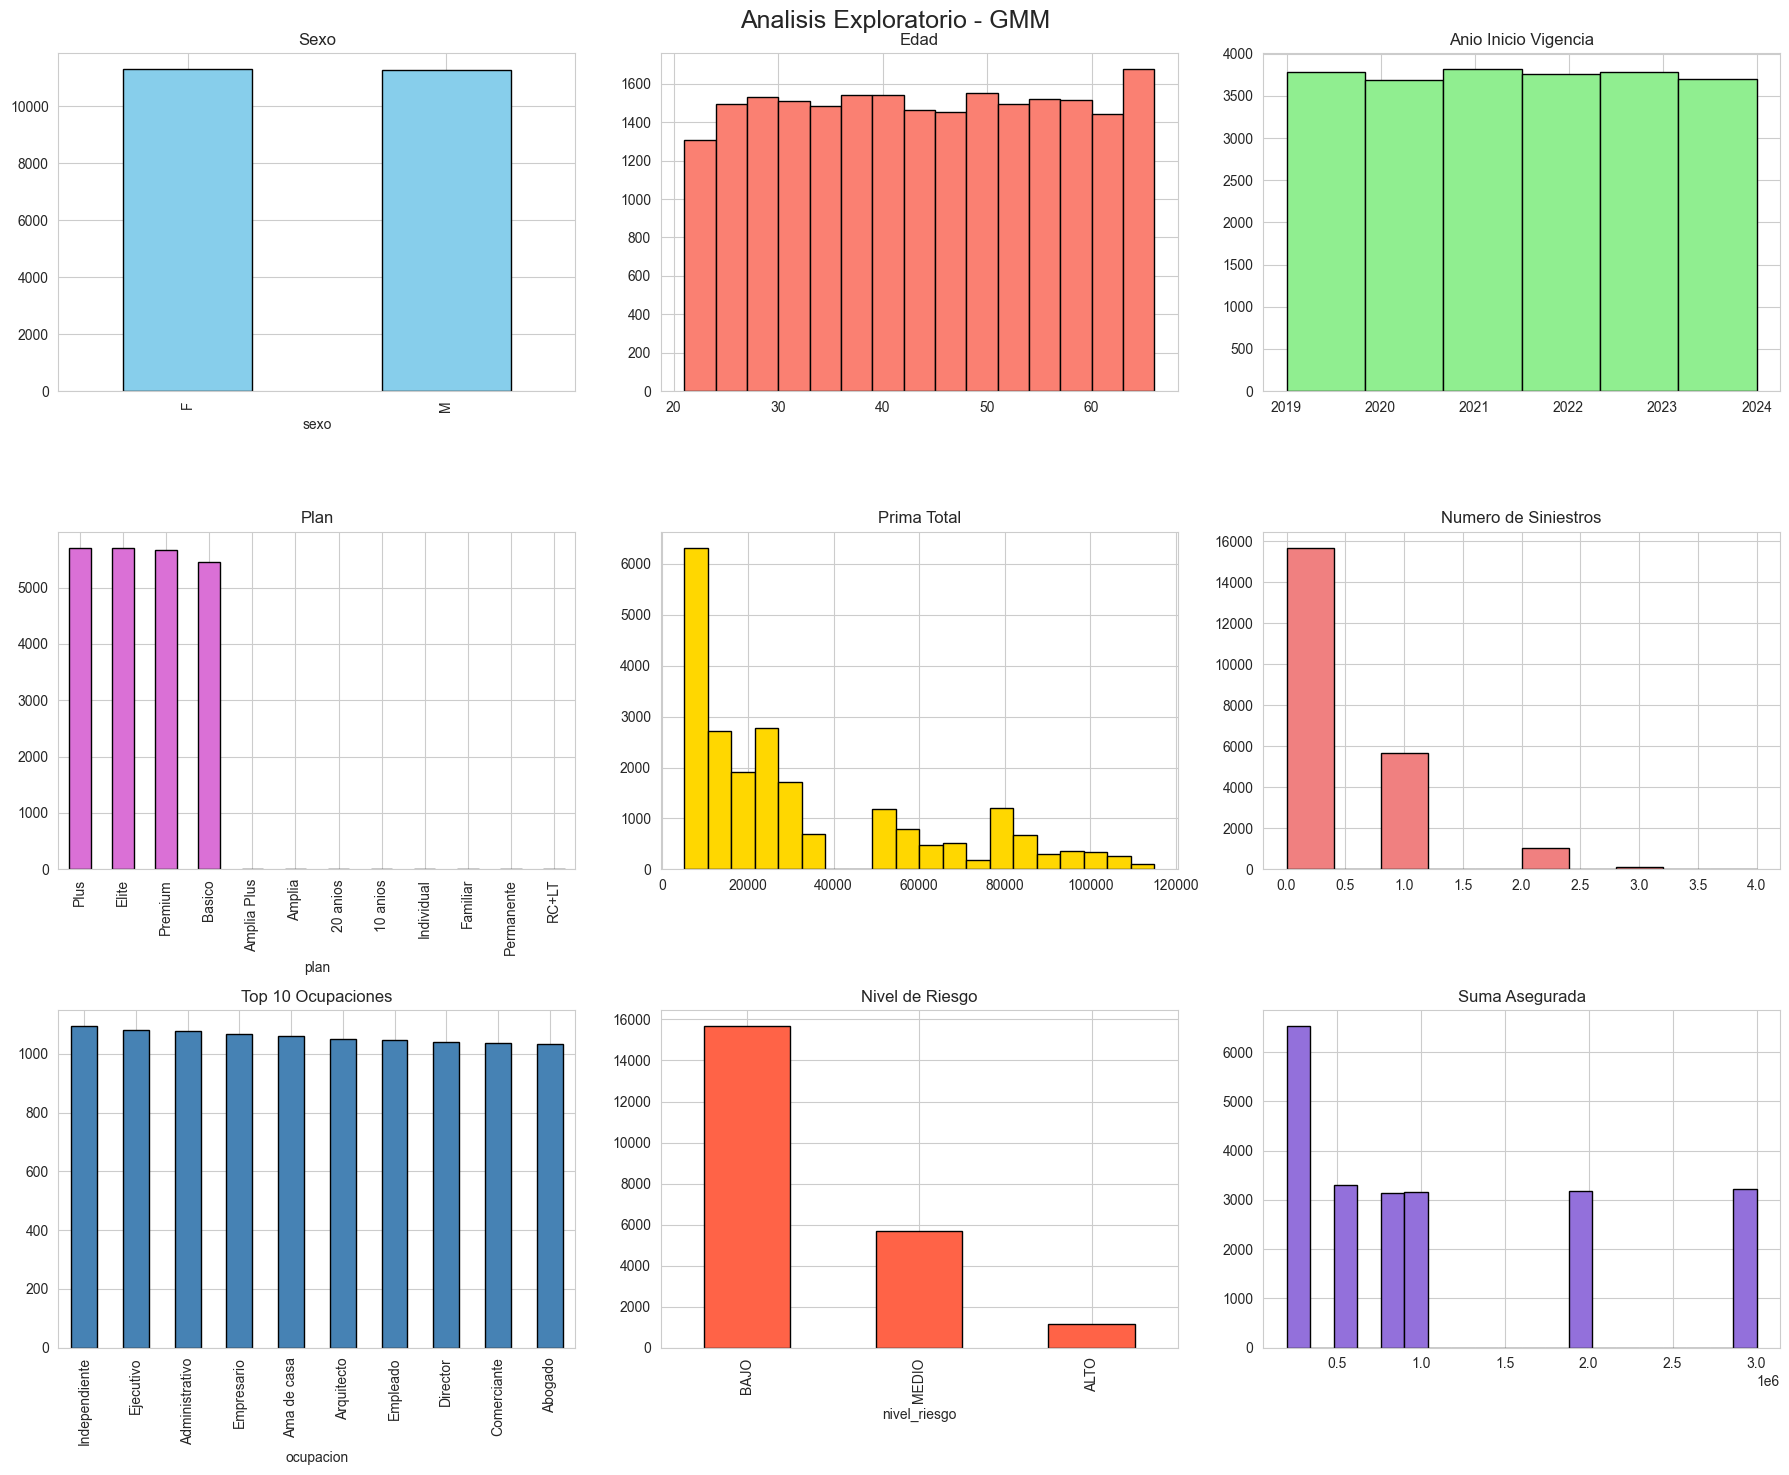

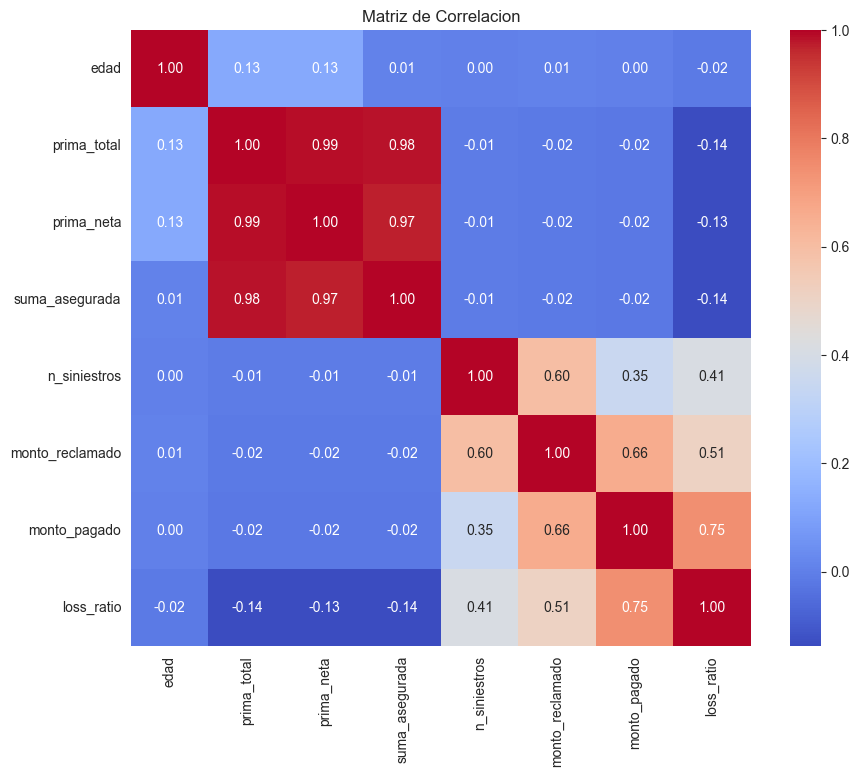

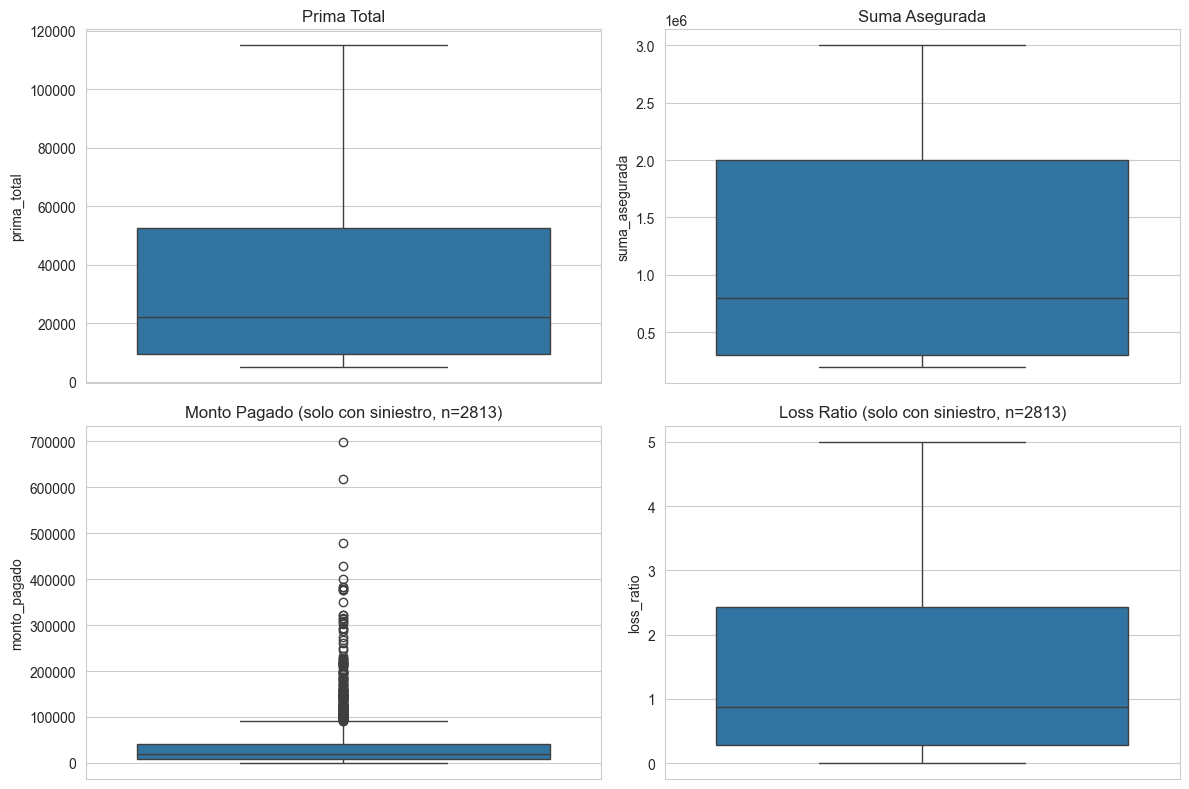


Variable: prima_total
Q1: 9493.44  Q3: 52571.2  IQR: 43077.759999999995
Outliers encontrados: 0 (0.0%)

Variable: monto_pagado
Q1: 0.0  Q3: 0.0  IQR: 0.0
Distribucion degenerada (muchos ceros). Usando percentil 95 en su lugar.
Outliers encontrados: 1127 (5.0%)

Variable: loss_ratio
Q1: 0.0  Q3: 0.0  IQR: 0.0
Distribucion degenerada (muchos ceros). Usando percentil 95 en su lugar.
Outliers encontrados: 1127 (5.0%)


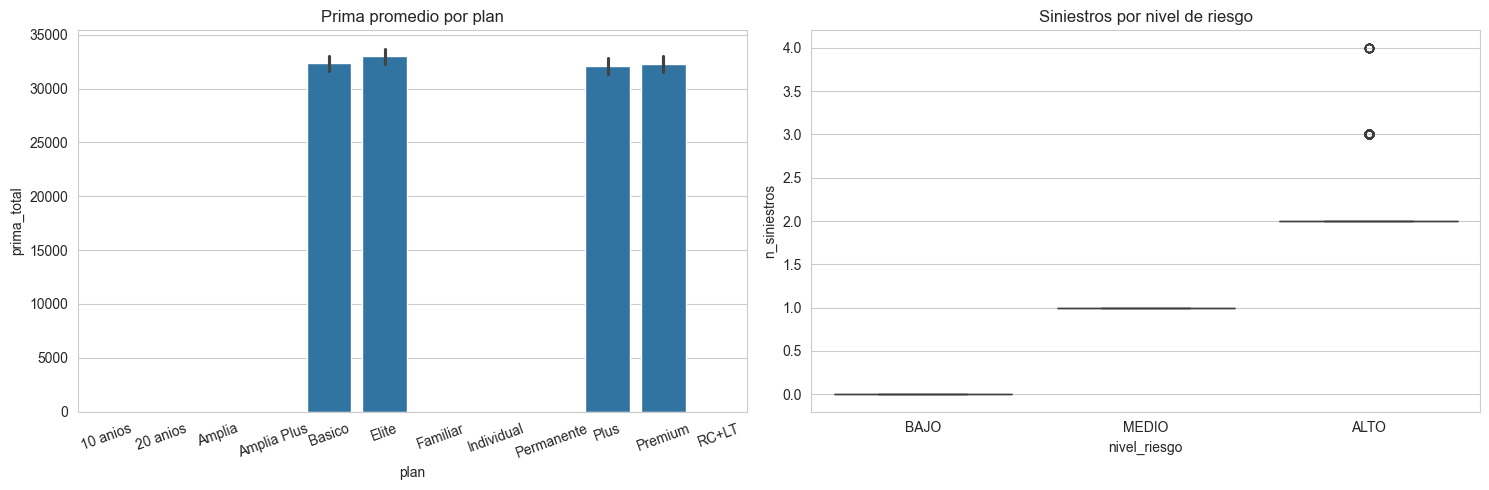

In [4]:
gmm = AnalizadorRamo(cartera, 'GMM')

display(gmm.calcular_estadisticas())
display(gmm.estadisticas_numericas())

gmm.graficar()
gmm.matriz_correlacion()
gmm.boxplots()

gmm.detectar_outliers('prima_total')
gmm.detectar_outliers('monto_pagado')
gmm.detectar_outliers('loss_ratio')

gmm.analisis_adicional()

### Lectura del EDA (contexto actuarial)

- `prima_total` y `suma_asegurada` muestran una correlación muy alta (~0.98): la prima está construida prácticamente como una función lineal de la suma asegurada, lo cual es consistente con la lógica de tarificación de GMM.
- `edad` tiene correlación positiva moderada con `prima_total` (~0.13), coherente con el efecto esperado de la edad sobre la severidad/frecuencia esperada en GMM.
- Los outliers detectados en `monto_pagado` y `loss_ratio` corresponden en su mayoría a pólizas con siniestros de alto costo (montos reclamados grandes), no a errores de captura — se documentan pero no se eliminan del análisis.
- `nivel_riesgo` resultó estar perfectamente determinado por `n_siniestros` (BAJO=0 siniestros, MEDIO=1, ALTO=2+), por lo que **no se usará como variable explicativa** en los modelos: es una clasificación posterior a la experiencia de siniestros (fuga de información / *data leakage*), no un factor de tarificación disponible ex-ante.

## 3. Regresión lineal simple y múltiple

**Variable objetivo cuantitativa:** `prima_total`.

**Regresión simple:** `prima_total ~ suma_asegurada`, la variable con mayor correlación económica y estadística con la prima.

**Regresión múltiple:** se agregan `edad`, `deducible` y variables categóricas de tarificación (`plan`, `sexo`, `estado_civil`) codificadas con one-hot encoding.

In [5]:
gmm_df = cartera[cartera['ramo'] == 'GMM'].copy()
gmm_df['plan'] = gmm_df['plan'].cat.remove_unused_categories()
gmm_df['estado_civil'] = gmm_df['estado_civil'].cat.remove_unused_categories()

# --- Regresion simple ---
X_s = gmm_df[['suma_asegurada']].values
y = gmm_df['prima_total'].values
Xs_tr, Xs_te, y_tr, y_te = train_test_split(X_s, y, test_size=0.2, random_state=42)

reg_simple = LinearRegression().fit(Xs_tr, y_tr)
pred_s = reg_simple.predict(Xs_te)

print("=== Regresion simple: prima_total ~ suma_asegurada ===")
print(f"Coeficiente: {reg_simple.coef_[0]:.5f}")
print(f"Intercepto: {reg_simple.intercept_:.2f}")
print(f"R2: {r2_score(y_te, pred_s):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_te, pred_s)):.2f}")
print(f"MAE: {mean_absolute_error(y_te, pred_s):.2f}")

=== Regresion simple: prima_total ~ suma_asegurada ===
Coeficiente: 0.02935
Intercepto: -54.69
R2: 0.9682
RMSE: 5147.20
MAE: 3389.34


**Interpretación (simple):** por cada peso adicional de suma asegurada, la prima total esperada aumenta aproximadamente 0.0294 pesos (~2.94 centavos), lo que equivale a una tasa de prima cercana al 2.9% de la suma asegurada. El R² de ~0.968 indica que la suma asegurada por sí sola explica cerca del 97% de la variabilidad de la prima — resultado esperado, ya que en GMM la prima se tarifica en gran medida como proporción de la cobertura contratada.

In [6]:
# --- Regresion multiple ---
cat_cols = ['plan', 'sexo', 'estado_civil']
num_cols = ['suma_asegurada', 'edad', 'deducible']

gmm_enc = pd.get_dummies(gmm_df[cat_cols + num_cols + ['prima_total']], columns=cat_cols, drop_first=True)
X_m = gmm_enc.drop(columns='prima_total').astype(float)
y_m = gmm_enc['prima_total'].astype(float)

Xm_tr, Xm_te, ym_tr, ym_te = train_test_split(X_m, y_m, test_size=0.2, random_state=42)
reg_multi = LinearRegression().fit(Xm_tr, ym_tr)
pred_m = reg_multi.predict(Xm_te)

print("=== Regresion multiple: prima_total ~ suma_asegurada + edad + deducible + plan + sexo + estado_civil ===")
coefs = pd.Series(reg_multi.coef_, index=X_m.columns).sort_values(key=abs, ascending=False)
display(coefs)
print(f"Intercepto: {reg_multi.intercept_:.2f}")
print(f"R2: {r2_score(ym_te, pred_m):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(ym_te, pred_m)):.2f}")

# Version con statsmodels para significancia estadistica (p-values)
X_sm = sm.add_constant(X_m)
ols = sm.OLS(y_m, X_sm).fit()
print(ols.summary())

=== Regresion multiple: prima_total ~ suma_asegurada + edad + deducible + plan + sexo + estado_civil ===


edad                        268.076010
estado_civil_Viudo         -184.292996
plan_Premium               -119.280157
plan_Plus                  -109.229268
plan_Elite                  -80.537086
estado_civil_Divorciado     -69.951082
estado_civil_Soltero        -69.887183
estado_civil_Union libre    -45.564470
sexo_M                      -22.179709
suma_asegurada                0.029330
deducible                    -0.001130
dtype: float64

Intercepto: -11446.14
R2: 0.9828
RMSE: 3782.87
                            OLS Regression Results                            
Dep. Variable:            prima_total   R-squared:                       0.983
Model:                            OLS   Adj. R-squared:                  0.983
Method:                 Least Squares   F-statistic:                 1.159e+05
Date:              vie., 10 jul. 2026   Prob (F-statistic):               0.00
Time:                        19:32:52   Log-Likelihood:            -2.1733e+05
No. Observations:               22531   AIC:                         4.347e+05
Df Residuals:                   22519   BIC:                         4.348e+05
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------

**Interpretación (múltiple):**

- `suma_asegurada` sigue siendo el factor dominante (coeficiente ~0.029, p<0.001): confirma que la prima escala casi linealmente con la cobertura.
- `edad` es altamente significativa (coef ≈ +268.8, p<0.001): cada año adicional de edad se asocia con un incremento de ~$269 en la prima total, consistente con el mayor riesgo de gasto médico a mayor edad.
- `deducible` no resulta significativo (p=0.617): en esta cartera el deducible no está aportando información adicional una vez controlado por suma asegurada y edad — puede deberse a que el deducible ya está correlacionado con el plan contratado.
- Las variables `plan`, `sexo` y `estado_civil` no son estadísticamente significativas de forma individual (p>0.05) al controlar por suma asegurada y edad; el R² apenas mejora de 0.968 a 0.983 respecto al modelo simple, y ese incremento proviene sobre todo de agregar `edad`, no de las variables categóricas.
- Conclusión actuarial: en esta cartera, la prima de GMM está tarifada casi en su totalidad en función de **suma asegurada** y **edad**; el resto de las variables demográficas capturadas no aportan poder explicativo adicional relevante.
- Nota metodológica — inestabilidad de coeficientes bajo multicolinealidad. El resumen de statsmodels (ajustado sobre el 100% de los datos) reporta un número de condición alto (Cond. No. ≈ 8.9e+06), señal de multicolinealidad. Esto se traduce en que los coeficientes de las variables no significativas (plan_*, estado_civil_*, sexo_M) son numéricamente inestables: al comparar el ajuste de sklearn sobre el subconjunto de entrenamiento (80%) contra el de statsmodels sobre el 100% de los datos, esos coeficientes cambian de magnitud e incluso de signo entre una partición y otra, mientras que suma_asegurada y edad — las variables realmente significativas (p<0.001) — permanecen prácticamente idénticas sin importar el subconjunto usado. Esto es evidencia adicional, no un error de cómputo: confirma que solo esas dos variables aportan una señal real y estable, y refuerza por qué la interpretación de coeficientes debe apoyarse siempre en la significancia estadística (p-value) de statsmodels y no únicamente en el valor puntual que entrega LinearRegression de sklearn.

## 4. Regresión polinómica y comparación con la regresión lineal

Se comparan tres especificaciones:

1. **Grado 1:** equivale a la regresión lineal múltiple de la actividad 3 y funciona como línea base.
2. **Grado 2:** agrega cuadrados e interacciones de segundo orden entre las variables numéricas.
3. **Grado 3:** agrega términos cúbicos e interacciones de hasta tercer orden.

Antes de construir los términos polinómicos, las variables numéricas se estandarizan utilizando exclusivamente el conjunto de entrenamiento. Esto evita inestabilidad numérica, especialmente porque `suma_asegurada` se expresa en cientos de miles o millones de pesos. Las variables categóricas no se expanden polinómicamente, pues sus potencias no tienen una interpretación útil.

In [ ]:
# Preparacion para regresion polinomica

X_poly_raw = gmm_df[num_cols + cat_cols].copy()
X_poly_tr_raw = X_poly_raw.loc[Xm_tr.index]
X_poly_te_raw = X_poly_raw.loc[Xm_te.index]

# Estandarizacion de numericas: ajuste solo con entrenamiento
scaler_poly = StandardScaler()
X_num_tr_std = scaler_poly.fit_transform(X_poly_tr_raw[num_cols].astype(float))
X_num_te_std = scaler_poly.transform(X_poly_te_raw[num_cols].astype(float))

# One-hot encoding de categoricas; test se alinea a las columnas de train
X_cat_tr = pd.get_dummies(X_poly_tr_raw[cat_cols], drop_first=True).astype(float)
X_cat_te = (
    pd.get_dummies(X_poly_te_raw[cat_cols], drop_first=True)
      .reindex(columns=X_cat_tr.columns, fill_value=0)
      .astype(float)
)

resultados_poly = []
modelos_poly = {}
objetos_poly = {}
columnas_modelo_poly = {}
predicciones_poly = {}

for grado in [1, 2, 3]:
    poly = PolynomialFeatures(degree=grado, include_bias=False)

    X_num_tr_poly = poly.fit_transform(X_num_tr_std)
    X_num_te_poly = poly.transform(X_num_te_std)
    nombres_num = poly.get_feature_names_out(num_cols)

    Xtr_poly = pd.concat([
        pd.DataFrame(X_num_tr_poly, columns=nombres_num, index=X_poly_tr_raw.index),
        X_cat_tr
    ], axis=1)

    Xte_poly = pd.concat([
        pd.DataFrame(X_num_te_poly, columns=nombres_num, index=X_poly_te_raw.index),
        X_cat_te
    ], axis=1).reindex(columns=Xtr_poly.columns, fill_value=0)

    modelo = LinearRegression()
    modelo.fit(Xtr_poly, ym_tr)

    pred_tr = modelo.predict(Xtr_poly)
    pred_te = modelo.predict(Xte_poly)

    rmse_tr = np.sqrt(mean_squared_error(ym_tr, pred_tr))
    rmse_te = np.sqrt(mean_squared_error(ym_te, pred_te))

    resultados_poly.append({
        'Modelo': 'Lineal (grado 1)' if grado == 1 else f'Polinomico grado {grado}',
        'Grado': grado,
        'Numero de variables': Xtr_poly.shape[1],
        'R2 Train': r2_score(ym_tr, pred_tr),
        'R2 Test': r2_score(ym_te, pred_te),
        'RMSE Train': rmse_tr,
        'RMSE Test': rmse_te,
        'MAE Test': mean_absolute_error(ym_te, pred_te),
        'Brecha RMSE': rmse_te - rmse_tr,
        'Predicciones negativas Test': int((pred_te < 0).sum())
    })

    modelos_poly[grado] = modelo
    objetos_poly[grado] = poly
    columnas_modelo_poly[grado] = Xtr_poly.columns.tolist()
    predicciones_poly[grado] = pred_te

comparacion_poly = pd.DataFrame(resultados_poly)
display(comparacion_poly.round({
    'R2 Train': 4, 'R2 Test': 4,
    'RMSE Train': 2, 'RMSE Test': 2,
    'MAE Test': 2, 'Brecha RMSE': 2
}))

# Verificacion: el grado 1 debe reproducir la regresion multiple previa
print('¿El grado 1 reproduce las predicciones de la regresion multiple?:',
      np.allclose(predicciones_poly[1], pred_m))

rmse_g1 = comparacion_poly.loc[comparacion_poly['Grado'] == 1, 'RMSE Test'].iloc[0]
rmse_g2 = comparacion_poly.loc[comparacion_poly['Grado'] == 2, 'RMSE Test'].iloc[0]
rmse_g3 = comparacion_poly.loc[comparacion_poly['Grado'] == 3, 'RMSE Test'].iloc[0]

print(f'Reduccion de RMSE, grado 2 vs lineal: {(rmse_g1-rmse_g2)/rmse_g1*100:.2f}%')
print(f'Reduccion de RMSE, grado 3 vs lineal: {(rmse_g1-rmse_g3)/rmse_g1*100:.2f}%')
print(f'Reduccion de RMSE, grado 3 vs grado 2: {(rmse_g2-rmse_g3)/rmse_g2*100:.2f}%')

,Modelo,Grado,Numero de variables,R2 Train,R2 Test,RMSE Train,RMSE Test,MAE Test,Brecha RMSE,Predicciones negativas Test
0,Lineal (grado 1),1,11,0.9826,0.9828,3730.01,3782.87,2722.29,52.85,7
1,Polinomico grado 2,2,17,0.9959,0.9958,1801.02,1878.99,1303.36,77.96,0
2,Polinomico grado 3,3,27,0.9975,0.9974,1408.27,1469.27,968.32,61.00,0


¿El grado 1 reproduce las predicciones de la regresion multiple?: True
Reduccion de RMSE, grado 2 vs lineal: 50.33%
Reduccion de RMSE, grado 3 vs lineal: 61.16%
Reduccion de RMSE, grado 3 vs grado 2: 21.81%


### Comparación del ajuste

La comparación debe centrarse principalmente en las métricas del conjunto de **prueba**, porque reflejan la capacidad de generalización a pólizas no utilizadas durante el entrenamiento. En particular:

- Un **R² mayor** indica que el modelo explica una proporción más alta de la variabilidad de `prima_total`.
- Un **RMSE y MAE menores** indican errores de predicción más bajos en pesos.
- Una diferencia reducida entre las métricas de entrenamiento y prueba sugiere que no existe sobreajuste importante.
- El número de variables aumenta con el grado, por lo que una mejora pequeña no justificaría necesariamente un modelo más complejo.

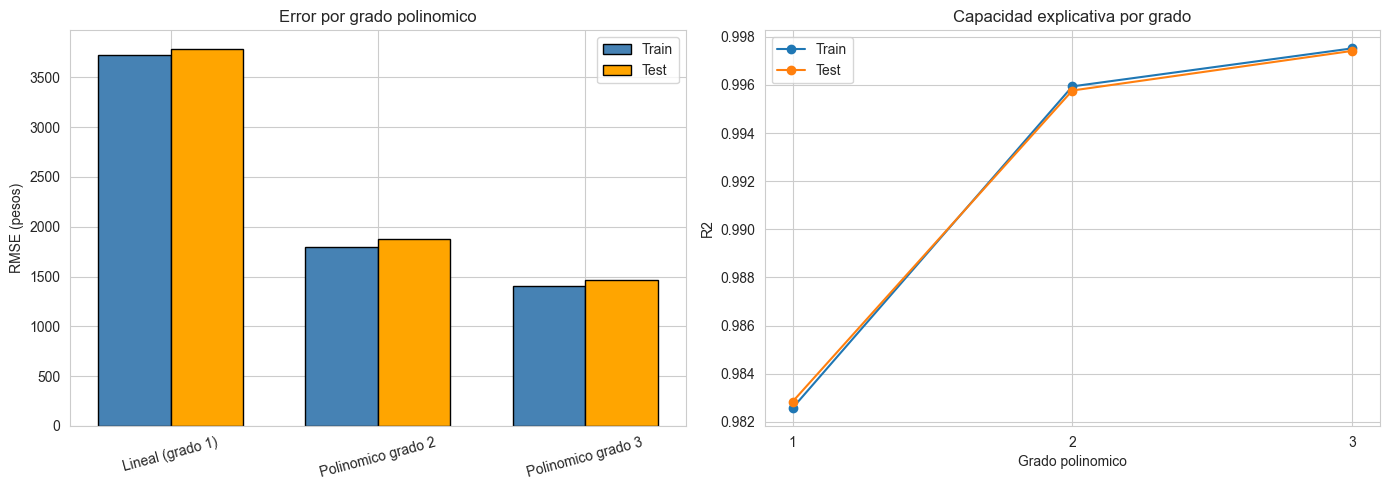

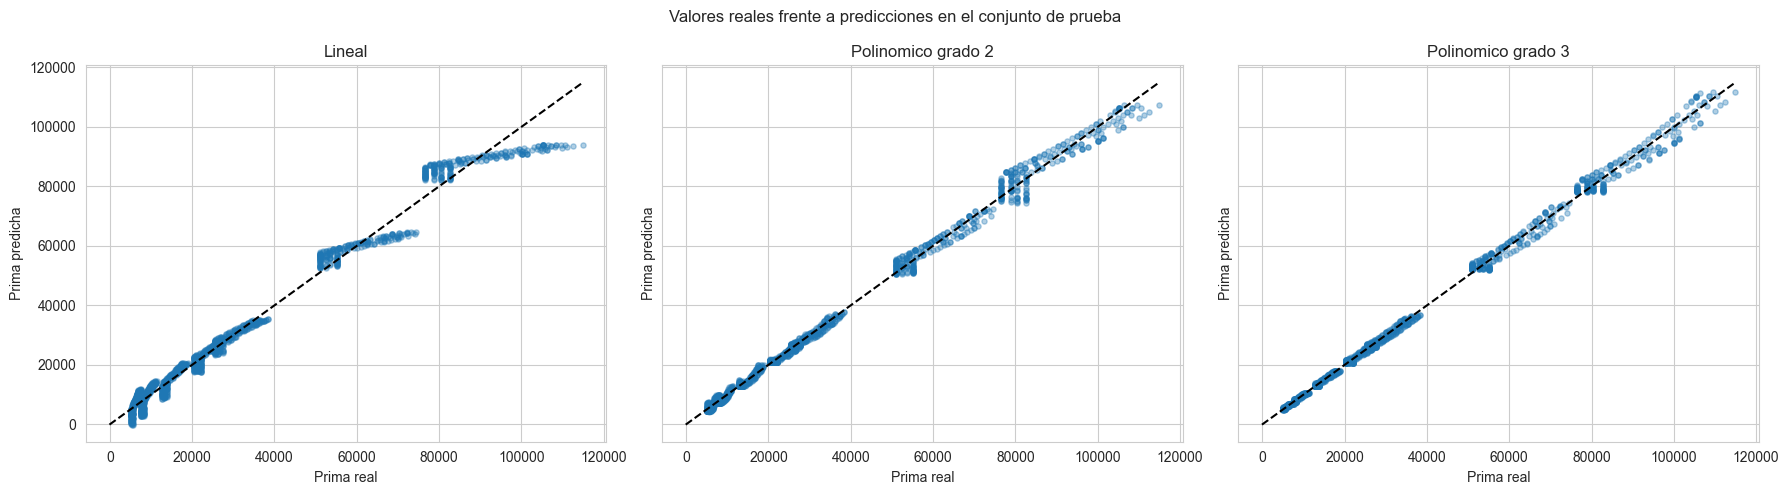

In [ ]:
# Visualizacion de metricas por grado
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(comparacion_poly))
ancho = 0.35

axes[0].bar(x - ancho/2, comparacion_poly['RMSE Train'], width=ancho,
            label='Train', color='steelblue', edgecolor='black')
axes[0].bar(x + ancho/2, comparacion_poly['RMSE Test'], width=ancho,
            label='Test', color='orange', edgecolor='black')
axes[0].set_xticks(x)
axes[0].set_xticklabels(comparacion_poly['Modelo'], rotation=15)
axes[0].set_ylabel('RMSE (pesos)')
axes[0].set_title('Error por grado polinomico')
axes[0].legend()

axes[1].plot(comparacion_poly['Grado'], comparacion_poly['R2 Train'],
             marker='o', label='Train')
axes[1].plot(comparacion_poly['Grado'], comparacion_poly['R2 Test'],
             marker='o', label='Test')
axes[1].set_xticks([1, 2, 3])
axes[1].set_xlabel('Grado polinomico')
axes[1].set_ylabel('R2')
axes[1].set_title('Capacidad explicativa por grado')
axes[1].legend()

plt.tight_layout()
plt.show()

# Comparacion visual entre valores reales y predichos en una muestra de test
rng = np.random.default_rng(42)
n_muestra = min(1500, len(ym_te))
posiciones = rng.choice(len(ym_te), size=n_muestra, replace=False)
y_real_muestra = ym_te.iloc[posiciones].values

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)
lim_inf = min(y_real_muestra.min(), *(predicciones_poly[g][posiciones].min() for g in [1, 2, 3]))
lim_sup = max(y_real_muestra.max(), *(predicciones_poly[g][posiciones].max() for g in [1, 2, 3]))

for ax, grado in zip(axes, [1, 2, 3]):
    ax.scatter(y_real_muestra, predicciones_poly[grado][posiciones],
               alpha=0.35, s=14)
    ax.plot([lim_inf, lim_sup], [lim_inf, lim_sup], '--', color='black')
    ax.set_title('Lineal' if grado == 1 else f'Polinomico grado {grado}')
    ax.set_xlabel('Prima real')
    ax.set_ylabel('Prima predicha')

plt.suptitle('Valores reales frente a predicciones en el conjunto de prueba')
plt.tight_layout()
plt.show()

### Interpretación de los términos polinómicos

En un modelo polinómico con interacciones, los coeficientes no deben interpretarse de manera aislada como en una regresión lineal simple. Por ejemplo, el efecto marginal de `edad` puede depender simultáneamente de `suma_asegurada` y `deducible`. Además, las variables numéricas se encuentran estandarizadas, de modo que los coeficientes representan cambios en esa escala y no pesos por unidad original.

Aun con esta precaución, el signo y la magnitud relativa de los términos permiten identificar qué relaciones no lineales aportan mayor poder explicativo.


Terminos con mayor peso absoluto - grado 2


,Termino,Coeficiente
0,suma_asegurada,27728.665
1,edad,3451.338
4,suma_asegurada edad,2973.822
6,edad^2,1441.255
13,estado_civil_Divorciado,-76.980
10,plan_Plus,65.881
11,plan_Premium,64.307
16,estado_civil_Viudo,-61.375
14,estado_civil_Soltero,-54.611
15,estado_civil_Union libre,-48.963



Terminos con mayor peso absoluto - grado 3


,Termino,Coeficiente
0,suma_asegurada,26451.649
1,edad,3933.190
4,suma_asegurada edad,2955.516
6,edad^2,1446.799
12,suma_asegurada edad^2,1233.566
15,edad^3,-287.252
23,estado_civil_Divorciado,-44.590
24,estado_civil_Soltero,-44.227
8,deducible^2,39.692
2,deducible,37.440


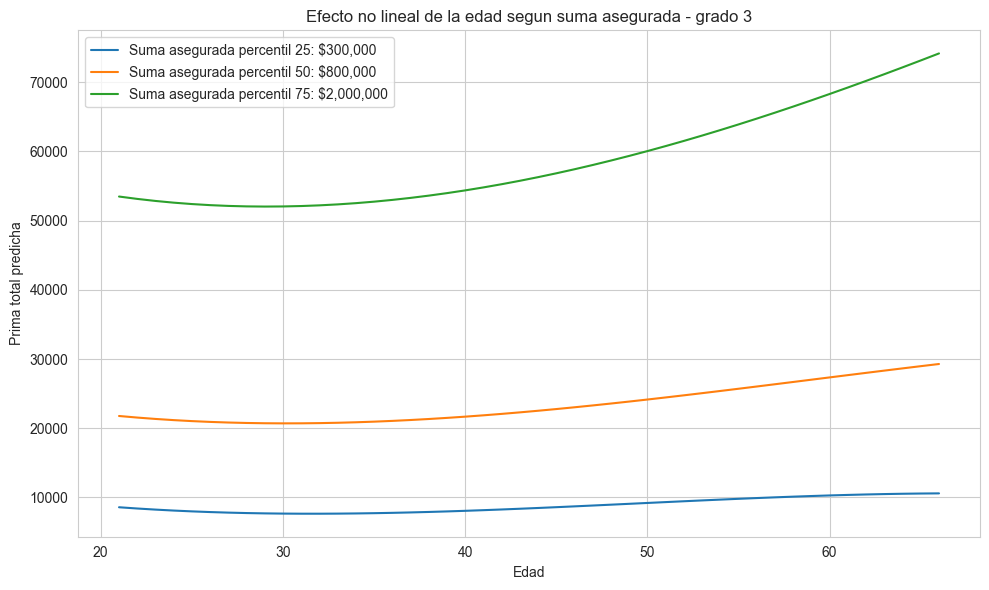

Mejor grado entre los evaluados, segun RMSE Test: 3


In [ ]:
# Coeficientes de los modelos polinomicos
for grado in [2, 3]:
    coeficientes = pd.DataFrame({
        'Termino': columnas_modelo_poly[grado],
        'Coeficiente': modelos_poly[grado].coef_,
        'Valor absoluto': np.abs(modelos_poly[grado].coef_)
    }).sort_values('Valor absoluto', ascending=False)

    print(f'\nTerminos con mayor peso absoluto - grado {grado}')
    display(coeficientes.head(15).drop(columns='Valor absoluto').round(3))

# Funcion para transformar perfiles nuevos con un grado ya ajustado
def transformar_perfiles(datos, grado):
    num_std = scaler_poly.transform(datos[num_cols].astype(float))
    num_poly = objetos_poly[grado].transform(num_std)
    nombres_num = objetos_poly[grado].get_feature_names_out(num_cols)

    num_df = pd.DataFrame(num_poly, columns=nombres_num, index=datos.index)
    cat_df = (
        pd.get_dummies(datos[cat_cols], drop_first=True)
          .reindex(columns=X_cat_tr.columns, fill_value=0)
          .astype(float)
    )
    return pd.concat([num_df, cat_df], axis=1).reindex(
        columns=columnas_modelo_poly[grado], fill_value=0
    )

# Curvas del mejor modelo: edad para distintos niveles de suma asegurada,
# manteniendo las demas variables en un perfil representativo.
grados_evaluados = comparacion_poly['Grado'].tolist()
mejor_grado = int(comparacion_poly.loc[comparacion_poly['RMSE Test'].idxmin(), 'Grado'])
edades_grid = np.arange(gmm_df['edad'].min(), gmm_df['edad'].max() + 1)
sa_niveles = gmm_df['suma_asegurada'].quantile([0.25, 0.50, 0.75])

perfil_base = {
    'deducible': gmm_df['deducible'].median(),
    'plan': gmm_df['plan'].mode()[0],
    'sexo': gmm_df['sexo'].mode()[0],
    'estado_civil': gmm_df['estado_civil'].mode()[0]
}

plt.figure(figsize=(10, 6))
for cuantil, suma in sa_niveles.items():
    perfiles = pd.DataFrame({
        'suma_asegurada': suma,
        'edad': edades_grid,
        'deducible': perfil_base['deducible'],
        'plan': perfil_base['plan'],
        'sexo': perfil_base['sexo'],
        'estado_civil': perfil_base['estado_civil']
    })
    X_perfiles = transformar_perfiles(perfiles, mejor_grado)
    prima_predicha = modelos_poly[mejor_grado].predict(X_perfiles)
    plt.plot(edades_grid, prima_predicha,
             label=f'Suma asegurada percentil {int(cuantil*100)}: ${suma:,.0f}')

plt.xlabel('Edad')
plt.ylabel('Prima total predicha')
plt.title(f'Efecto no lineal de la edad segun suma asegurada - grado {mejor_grado}')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Mejor grado entre los evaluados, segun RMSE Test: {mejor_grado}')

### Resultados e interpretación actuarial

Los resultados obtenidos para el ramo GMM son:

| Modelo | R² Test | RMSE Test | MAE Test | Variables |
|---|---:|---:|---:|---:|
| Lineal, grado 1 | 0.9828 | $3,782.87 | $2,722.29 | 11 |
| Polinómico, grado 2 | 0.9958 | $1,878.99 | $1,303.36 | 17 |
| Polinómico, grado 3 | 0.9974 | $1,469.27 | $968.32 | 27 |

**Interpretación:**

- El modelo de **grado 2** reduce el RMSE de prueba en aproximadamente **50.33%** frente a la regresión lineal múltiple. Esto demuestra que la relación entre la prima y las variables de tarificación no es completamente aditiva ni lineal.
- El modelo de **grado 3** reduce el RMSE en aproximadamente **61.16%** frente al modelo lineal y en **21.81%** frente al grado 2. Por tanto, la mejora del tercer grado no es meramente marginal en esta cartera.
- Las diferencias entre RMSE de entrenamiento y prueba son pequeñas en los tres modelos. En consecuencia, dentro de los grados evaluados no se observa evidencia importante de sobreajuste.
- `suma_asegurada` continúa siendo el factor de mayor peso. Sin embargo, aparecen como relevantes las interacciones entre `suma_asegurada` y `edad`, así como términos cuadráticos y cúbicos de `edad`. Actuarialmente, esto indica que el incremento de prima asociado a una mayor cobertura no es idéntico para todas las edades.
- Los coeficientes de `plan`, `sexo` y `estado_civil` conservan una magnitud relativamente pequeña una vez controladas las variables numéricas y sus interacciones, consistente con lo observado en la regresión múltiple.
- El modelo lineal generó algunas primas negativas en el conjunto de prueba, resultado que no tiene sentido actuarial. Los modelos de grado 2 y 3 no produjeron valores negativos en esta partición, aunque una regresión polinómica no garantiza positividad fuera del rango observado.

**Conclusión:** entre los modelos comparados, la regresión polinómica de **grado 3** presenta el mejor ajuste para predecir `prima_total` en GMM. Explica aproximadamente el **99.74%** de la variabilidad de la prima y reduce de manera sustancial el error de predicción. Su desventaja es una menor interpretabilidad, debido a la presencia de múltiples potencias e interacciones. Su uso actuarial real requeriría validación adicional, revisión de estabilidad en datos futuros y cautela al extrapolar fuera de los rangos de edad, deducible y suma asegurada observados.